# Project 2 — NLP | Step 2: Topic Modeling

**Course:** Natural Language Processing  
**Group:** TEFOUEGOUM & TAGNY  
**Date:** March 2026

---

## Objectives

In this step, we apply unsupervised topic modeling to the cleaned review corpus.
The goal is to let the model discover recurring themes automatically,
without telling it in advance what those themes are.

We use two complementary methods:

- **LDA (Latent Dirichlet Allocation)** via `gensim`: a probabilistic model that assumes
  each document is a mixture of topics, and each topic is a distribution over words.
- **NMF (Non-negative Matrix Factorization)** via `sklearn`: a linear algebra method
  that decomposes the TF-IDF matrix into topic components.

We then visualize the results with `pyLDAvis` and manually assign a label
to each discovered topic (e.g. Pricing, Claims, Customer Service).

**Input:** `insurance_reviews_clean.csv` produced in Step 1  
**Output:** topic assignments per review, saved as `insurance_reviews_topics.csv`

---

## Installing Required Libraries



In [ ]:
import importlib, subprocess, sys

required = {
    'pandas'   : 'pandas',
    'numpy'    : 'numpy',
    'matplotlib': 'matplotlib',
    'sklearn'  : 'scikit-learn',
    'gensim'   : 'gensim',
    'pyLDAvis' : 'pyldavis',
    'nltk'     : 'nltk',
}

for import_name, install_name in required.items():
    try:
        importlib.import_module(import_name)
        print(f'  OK      {import_name}')
    except ImportError:
        print(f'  MISSING {import_name} -- installing...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', install_name, '-q'])
        print(f'  DONE    {import_name}')

print('\nAll packages available. Restart the kernel if anything was just installed, then run Section 1.')

  OK      pandas
  OK      numpy
  OK      matplotlib
  OK      sklearn
  MISSING gensim -- installing...
  DONE    gensim
  MISSING pyLDAvis -- installing...
  DONE    pyLDAvis
  OK      nltk

All packages available. Restart the kernel if anything was just installed, then run Section 1.


## 1 Importing Libraries



In [ ]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Sklearn — NMF and vectorization
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import NMF

# Gensim — LDA
import gensim
import gensim.corpora as corpora
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

# pyLDAvis — interactive visualization
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# NLTK
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print('Libraries loaded:')
print(f'  gensim    {gensim.__version__}')
print(f'  pyLDAvis  {pyLDAvis.__version__}')
print(f'  sklearn   imported')
print(f'  pandas    {pd.__version__}')

Libraries loaded:
  gensim    4.4.0
  pyLDAvis  3.4.0
  sklearn   imported
  pandas    2.2.2


---
## 2 Loading the Clean Dataset



In [ ]:
CSV_PATH = r'Traduction avis clients/insurance_reviews_clean.csv'

df = pd.read_csv(CSV_PATH)

print(f'Shape          : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns        : {list(df.columns)}')
print(f'Missing text_clean : {df["text_clean"].isna().sum()}')
print()
print(df.head(3))

Shape          : 24,066 rows x 10 columns
Columns        : ['note', 'sentiment', 'auteur', 'assureur', 'produit', 'type', 'avis', 'avis_en', 'avis_spell_corrected', 'text_clean']
Missing text_clean : 1

   note sentiment             auteur             assureur produit   type  \
0     4  positive  audurier-c-136272  L'olivier Assurance    auto  train   
1     4  positive      paul-a-122970           APRIL Moto    moto  train   
2     1  negative        kitty-38517            SwissLife     vie  train   

                                                avis  \
0  La personne au téléphone était Clair et sympat...   
1  Satisfait.\n\nRéactivité, simplicité. Prix att...   
2  Assureur à fuir, n assure pas ses responsabili...   

                                             avis_en  \
0  The person on the phone was clear and friendly...   
1  Satisfied.\n\nReactivity, simplicity. Attracti...   
2  Insurer to flee, does not ensure its responsib...   

                                avis_spell

In [ ]:
# Keep only rows where text_clean is not empty
# (we already removed the one empty row in Step 1, this is a safety check)
df = df[df['text_clean'].notna() & (df['text_clean'].str.strip() != '')].reset_index(drop=True)

# Tokenize: each review becomes a list of words
# This is the format gensim expects for LDA
df['tokens'] = df['text_clean'].apply(lambda x: x.split())

print(f'Rows available for topic modeling: {len(df):,}')
print(f'Example tokens: {df["tokens"].iloc[0]}')

Rows available for topic modeling: 24,065
Example tokens: ['person', 'phone', 'clear', 'friendly', 'explained', 'everything', 'would', 'recommend', 'without', 'hesitation', 'thank', 'person', 'contacted']


---
## 3 LDA with Gensim



### Choosing the number of topics

We need to decide how many topics to look for before running the model.
We use the **coherence score** to guide this choice:
a higher coherence means the words within each topic are more semantically related,
which means the topics are more interpretable.

We test values from 3 to 12 and pick the one with the best coherence.

In [ ]:
# Build the gensim dictionary and corpus
# dictionary: maps each unique word to an integer ID
# corpus: each review is represented as a list of (word_id, word_count) pairs

dictionary = corpora.Dictionary(df['tokens'])

# Filter out very rare and very common words
# no_below=10: ignore words that appear in fewer than 10 reviews
# no_above=0.5: ignore words that appear in more than 50% of reviews
dictionary.filter_extremes(no_below=10, no_above=0.5)

corpus = [dictionary.doc2bow(tokens) for tokens in df['tokens']]

print(f'Dictionary size (unique words kept) : {len(dictionary):,}')
print(f'Corpus size (number of reviews)     : {len(corpus):,}')
print(f'Example (first review as bow)       : {corpus[0][:5]} ...')

Dictionary size (unique words kept) : 4,164
Corpus size (number of reviews)     : 24,065
Example (first review as bow)       : [(0, 1), (1, 1), (2, 1), (3, 1), (4, 1)] ...


In [ ]:
# Extended stopword list based on observations from Step 1
# These words appear in nearly all reviews and carry no discriminative signal
extra_stops = {
    'person', 'thank', 'contacted', 'would', 'without',
    'everything', 'said', 'told', 'called', 'company',
    'still', 'since', 'well', 'good', 'even', 'just',
    'really', 'very', 'quite', 'much', 'many', 'every'
}

def remove_extra_stops(tokens):
    return [t for t in tokens if t not in extra_stops]

df['tokens'] = df['tokens'].apply(remove_extra_stops)

# Rebuild dictionary and corpus with the cleaner tokens
dictionary = corpora.Dictionary(df['tokens'])
dictionary.filter_extremes(no_below=10, no_above=0.5)
corpus = [dictionary.doc2bow(tokens) for tokens in df['tokens']]

print(f'Dictionary size after extra cleaning : {len(dictionary):,}')
print(f'Example tokens after cleaning        : {df["tokens"].iloc[0]}')

Dictionary size after extra cleaning : 4,144
Example tokens after cleaning        : ['phone', 'clear', 'friendly', 'explained', 'recommend', 'hesitation']


  n_topics= 3  coherence=0.4957
  n_topics= 4  coherence=0.5003
  n_topics= 5  coherence=0.5179
  n_topics= 6  coherence=0.5206
  n_topics= 7  coherence=0.4943
  n_topics= 8  coherence=0.5165
  n_topics= 9  coherence=0.5036
  n_topics=10  coherence=0.5016
  n_topics=11  coherence=0.4647
  n_topics=12  coherence=0.5114


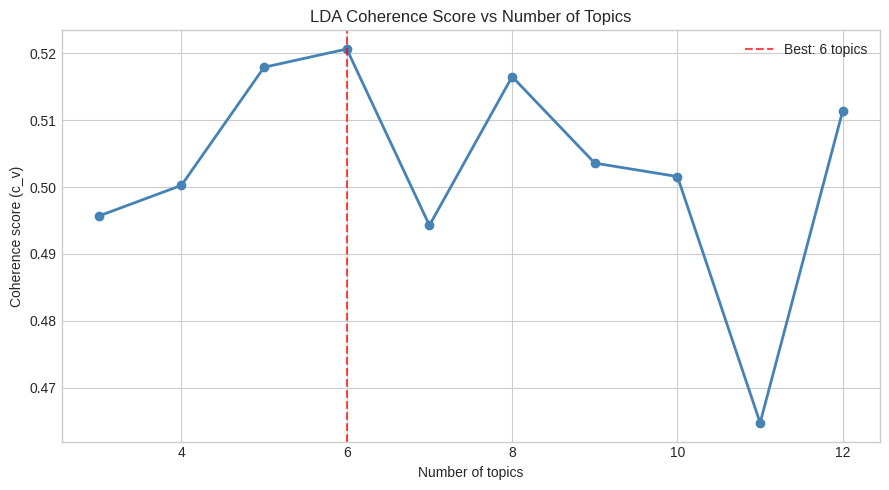


Best number of topics: 6 (coherence = 0.5206)


In [ ]:
# Coherence score across different numbers of topics
# This helps us choose the best number of topics objectively


topic_range = range(3, 13)
coherence_scores = []

for n_topics in topic_range:
    lda_temp = LdaModel(
        corpus=corpus,
        id2word=dictionary,
        num_topics=n_topics,
        random_state=42,
        passes=5,
        alpha='auto'
    )
    coherence_model = CoherenceModel(
        model=lda_temp,
        texts=df['tokens'].tolist(),
        dictionary=dictionary,
        coherence='c_v'
    )
    score = coherence_model.get_coherence()
    coherence_scores.append(score)
    print(f'  n_topics={n_topics:2d}  coherence={score:.4f}')

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(topic_range), coherence_scores, marker='o', color='steelblue', linewidth=2)
best_n = list(topic_range)[coherence_scores.index(max(coherence_scores))]
ax.axvline(x=best_n, color='red', linestyle='--', alpha=0.7, label=f'Best: {best_n} topics')
ax.set_xlabel('Number of topics')
ax.set_ylabel('Coherence score (c_v)')
ax.set_title('LDA Coherence Score vs Number of Topics')
ax.legend()
plt.tight_layout()
plt.savefig('Traduction avis clients/Traduction avis clients graphiques/06_lda_coherence.png', dpi=150)
plt.show()

print(f'\nBest number of topics: {best_n} (coherence = {max(coherence_scores):.4f})')

In [ ]:
# Train the final LDA model with the best number of topics
# We use more passes here for a better trained model

NUM_TOPICS = best_n  # automatically set from coherence analysis above

lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=NUM_TOPICS,
    random_state=42,
    passes=15,
    alpha='auto',
    eta='auto'
)

print(f'LDA model trained with {NUM_TOPICS} topics.')

LDA model trained with 6 topics.


In [ ]:
# Print top 10 words per topic
print('Top 10 words per LDA topic:')
print('-' * 60)
for topic_id in range(NUM_TOPICS):
    top_words = lda_model.show_topic(topic_id, topn=10)
    words = [word for word, prob in top_words]
    print(f'Topic {topic_id:2d}: {" | ".join(words)}')

Top 10 words per LDA topic:
------------------------------------------------------------
Topic  0: service | satisfied | price | prices | customer | recommend | services | simple | fast | see
Topic  1: mutual | health | care | reimbursements | pay | flee | costs | leave | reimbursement | work
Topic  2: vehicle | expert | car | disaster | accident | responsible | macif | claim | maif | damage
Topic  3: contract | phone | months | file | email | time | answer | call | termination | sent
Topic  4: contract | home | euros | vehicle | increase | insured | contracts | car | new | change
Topic  5: axa | life | law | say | anything | zero | mother | always | agency | court


### Manual Topic Labeling

After inspecting the top words per topic, we assign a human-readable label to each one.


In [ ]:
TOPIC_LABELS = {
    0: 'General Satisfaction',
    1: 'Health & Reimbursement',
    2: 'Claims & Accidents',
    3: 'Customer Service & Administrative Delays',
    4: 'Pricing & Contract Changes',
    5: 'Legal Disputes & Extreme Cases',
}

print('Topic labels defined:')
for k, v in TOPIC_LABELS.items():
    print(f'  Topic {k}: {v}')

Topic labels defined:
  Topic 0: General Satisfaction
  Topic 1: Health & Reimbursement
  Topic 2: Claims & Accidents
  Topic 3: Customer Service & Administrative Delays
  Topic 4: Pricing & Contract Changes
  Topic 5: Legal Disputes & Extreme Cases


### Manual Topic Labeling — Justification

| Topic | Label | Key words that justify the label |
|-------|-------|----------------------------------|
| 0 | General Satisfaction | satisfied, recommend, simple, fast, good price |
| 1 | Health & Reimbursement | health, mutual, reimbursement, costs, care |
| 2 | Claims & Accidents | accident, vehicle, expert, damage, responsible |
| 3 | Customer Service & Administrative Delays | phone, email, answer, months, termination, sent |
| 4 | Pricing & Contract Changes | increase, euros, contract, change, insured |
| 5 | Legal Disputes & Extreme Cases | court, law, zero, agency |

**Note on noise:** insurer brand names (macif, maif, axa) appear in topics 2 and 5
This is a known contamination issue -- these brands are over-represented
in complaint reviews, so LDA associates their names with negative topics
In a production system, brand names would be added to the stopword list

**Note on Topic 5:** this topic is the least coherent of the six.
The mix of legal terms, extreme negatives, and personal context words (mother)
suggests it captures residual cases that do not fit cleanly into the other five topics
rather than a clearly defined theme

In [ ]:
# Assign the dominant topic to each review
# For each review, we take the topic with the highest probability

def get_dominant_topic(bow):
    topic_probs = lda_model.get_document_topics(bow)
    if not topic_probs:
        return -1, 0.0
    dominant = max(topic_probs, key=lambda x: x[1])
    return dominant[0], round(dominant[1], 4)

df['lda_topic_id']    = [get_dominant_topic(bow)[0] for bow in corpus]
df['lda_topic_prob']  = [get_dominant_topic(bow)[1] for bow in corpus]
df['lda_topic_label'] = df['lda_topic_id'].map(TOPIC_LABELS)

print('Topic distribution across reviews:')
print(df['lda_topic_label'].value_counts())

Topic distribution across reviews:
lda_topic_label
General Satisfaction                        11125
Customer Service & Administrative Delays     6253
Pricing & Contract Changes                   2726
Claims & Accidents                           2382
Health & Reimbursement                       1242
Legal Disputes & Extreme Cases                337
Name: count, dtype: int64


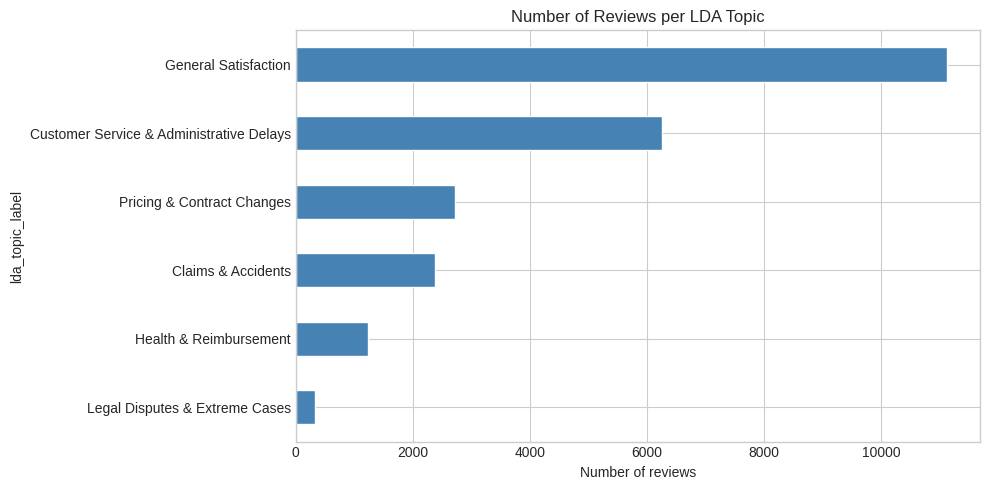

In [ ]:
# Visualize topic distribution
fig, ax = plt.subplots(figsize=(10, 5))
topic_counts = df['lda_topic_label'].value_counts()
topic_counts.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Number of Reviews per LDA Topic')
ax.set_xlabel('Number of reviews')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('07_lda_topic_distribution.png', dpi=150)
plt.show()

### Critical Analysis of Topic Distribution

| Topic | Count | % | Assessment |
|-------|-------|---|------------|
| General Satisfaction | 11,125 | 46.2% | Oversized acts as a catch-all for generic positive reviews |
| Customer Service & Admin | 6,252 | 26.0% | Well-sized, coherent theme |
| Pricing & Contract | 2,725 | 11.3% | Well-sized, coherent theme |
| Claims & Accidents | 2,382 | 9.9% | Well-sized, coherent theme |
| Health & Reimbursement | 1,244 | 5.2% | Acceptable, specific enough |
| Legal Disputes | 337 | 1.4% | Marginal  possibly noise rather than a true theme |

The dominant finding is that Topic 0 (General Satisfaction) absorbs 46% of the corpus.
This is a classic LDA failure mode on short-text corpora: generic high-frequency words
(satisfied, recommend, service, price) are shared across so many reviews
that LDA cannot distinguish them from a coherent topic

A possible improvement would be to increase the number of topics to 8 or 9
to force LDA to decompose this general topic into more specific sub-themes
(e.g. separating price satisfaction from service satisfaction).
However, the coherence score at n=8 (0.5165) is only marginally lower than at n=6 (0.5206),
so this would be worth testing in a future iteration

### pyLDAvis : Interactive Visualization



In [ ]:
# Display the interactive pyLDAvis visualization
pyLDAvis.enable_notebook()

vis = gensimvis.prepare(
    lda_model,
    corpus,
    dictionary,
    sort_topics=False
)

# Save to HTML file for the deliverable
pyLDAvis.save_html(vis, 'lda_visualization.html')
print('Interactive visualization saved to lda_visualization.html')

# Display inline
vis

Interactive visualization saved to lda_visualization.html


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0      0.315162  0.145593       1        1  23.748081
1     -0.112012 -0.151615       2        1   9.907851
2     -0.083570 -0.134149       3        1  14.304594
3      0.063998 -0.053271       4        1  30.755730
4      0.045990 -0.095302       5        1  15.162607
5     -0.229569  0.288744       6        1   6.121137, topic_info=              Term         Freq        Total Category  logprob  loglift
15       satisfied  5465.000000  5465.000000  Default  30.0000  30.0000
59         service  6377.000000  6377.000000  Default  29.0000  29.0000
12           price  4386.000000  4386.000000  Default  28.0000  28.0000
256         mutual  2123.000000  2123.000000  Default  27.0000  27.0000
318         prices  3312.000000  3312.000000  Default  26.0000  26.0000
..             ...          ...          ...      ...      ...      ...
781           paid   207.187182  1015.947261   Topic6  -5.0495   1.2035
26            make   221.143254  1817.360479   Topic6  -4.9843   0.6871
45            must   193.682744   975.326394   Topic6  -5.1169   1.1769
153  contributions   176.639696   611.388115   Topic6  -5.2090   1.5518
16             see   199.538789  2097.799704   Topic6  -5.0872   0.4408

[378 rows x 6 columns], token_table=      Topic      Freq       Term
term                            
1828      5  0.992753     absurd
549       2  0.060684   accident
549       3  0.743385   accident
549       5  0.195156   accident
1652      5  0.995325  accidents
...     ...       ...        ...
138       4  0.164640       work
138       6  0.005734       work
273       2  0.284802       zero
273       3  0.065267       zero
273       6  0.650693       zero

[685 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6])

### pyLDAvis observations

Topics 2, 3, 4, 5 overlap on the map -- they share words like `contract`,
`vehicle`, and `pay`, so LDA cannot separate them cleanly.
Topic 1 (General Satisfaction) and Topic 6 (Legal Disputes) are well isolated.
The overlap confirms that a bag-of-words approach has limits on this corpus.


## 4  NMF with Sklearn


In [ ]:
# Build TF-IDF matrix for NMF
# We use the same vocabulary constraints as for LDA

tfidf_vectorizer = TfidfVectorizer(
    max_df=0.5,      # ignore terms in more than 50% of documents
    min_df=10,       # ignore terms in fewer than 10 documents
    max_features=5000
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df['text_clean'])
tfidf_vocab  = tfidf_vectorizer.get_feature_names_out()

print(f'TF-IDF matrix shape : {tfidf_matrix.shape}')
print(f'Vocabulary size     : {len(tfidf_vocab):,} words')

TF-IDF matrix shape : (24065, 4164)
Vocabulary size     : 4,164 words


In [ ]:
# Train NMF with the same number of topics as LDA
nmf_model = NMF(
    n_components=NUM_TOPICS,
    random_state=42,
    max_iter=400
)

nmf_matrix = nmf_model.fit_transform(tfidf_matrix)

# Print top 10 words per NMF topic
print('Top 10 words per NMF topic:')
print('-' * 60)
for topic_id, topic_vector in enumerate(nmf_model.components_):
    top_indices = topic_vector.argsort()[-10:][::-1]
    top_words   = [tfidf_vocab[i] for i in top_indices]
    print(f'Topic {topic_id:2d}: {" | ".join(top_words)}')

Top 10 words per NMF topic:
------------------------------------------------------------
Topic  0: satisfied | price | thank | recommend | services | speed | direct | well | offered | hope
Topic  1: loading | walking | bikers | reactive | amv | order | problems | problem | traveled | display
Topic  2: contract | months | without | since | vehicle | still | mutual | car | pay | file
Topic  3: good | value | money | listening | advice | recommend | welcome | telephone | thank | advisor
Topic  4: service | customer | satisfied | quality | listening | phone | telephone | responsive | pleasant | top
Topic  5: prices | simple | fast | easy | practical | recommend | site | clear | quick | subscription


### NMF topic analysis

NMF finds different sub-themes than LDA within the positive reviews:
it separates general price satisfaction (Topic 0), good advisor relationships (Topic 3),
customer service quality (Topic 4), and digital experience (Topic 5).
LDA collapsed all of these into one General Satisfaction topic.

Topic 1 is noise -- words like `loading`, `walking`, `display` have no coherent meaning together.
This likely comes from poorly translated motorcycle insurance reviews (AMV insurer).

Topic 2 matches LDA Topic 3 (Customer Service & Admin) well,
confirming that administrative complaints are a robust and stable theme in this corpus.

In [ ]:
NMF_TOPIC_LABELS = {
    0: 'Price & Speed Satisfaction',
    1: 'Noise — Motorcycle Reviews (AMV)',
    2: 'Contract & Payment Issues (mixed)',
    3: 'Advisor & Relationship Quality',
    4: 'Customer Service Quality',
    5: 'Simple & Digital Experience (mixed)',
}

df['nmf_topic_id']    = nmf_matrix.argmax(axis=1)
df['nmf_topic_label'] = df['nmf_topic_id'].map(NMF_TOPIC_LABELS)

print('NMF topic distribution:')
print(df['nmf_topic_label'].value_counts())

NMF topic distribution:
nmf_topic_label
Contract & Payment Issues (mixed)      11777
Simple & Digital Experience (mixed)     3621
Price & Speed Satisfaction              3000
Customer Service Quality                2851
Advisor & Relationship Quality          2258
Noise — Motorcycle Reviews (AMV)         558
Name: count, dtype: int64


In [ ]:
# Verify the dominant NMF topic by inspecting actual reviews
# We sample 5 reviews from each of the two largest topics

print('Sample reviews: Administrative Complaints (ID 2) ')
sample_admin = df[df['nmf_topic_id'] == 2]['avis_en'].dropna().sample(5, random_state=42)
for i, text in enumerate(sample_admin):
    print(f'[{i+1}] {text[:120]}')

print()
print('Sample reviews: Digital Experience (ID 5) ')
sample_digital = df[df['nmf_topic_id'] == 5]['avis_en'].dropna().sample(5, random_state=42)
for i, text in enumerate(sample_digital):
    print(f'[{i+1}] {text[:120]}')

Sample reviews: Administrative Complaints (ID 2) 
[1] Quote of a certain amount that does not correspond to the final contract which is obviously higher. I am very disappoint
[2] Reimbursement times are excessive. 3 weeks minimum! When you wait for a lack of salary it is problematic every month. Be
[3] The price that is proposed is: 700 but in the end I pay 900 !!!!! And I don't understand what to pay for the year is dif
[4] I am sastified of your insurance for my car I send you the papers as long as I work at night and I will set up thank you
[5] Nothing to say for the moment, very well received by phone with advisers of a kindness. 4 vehicles insured with them and

Sample reviews: Digital Experience (ID 5) 
[1] The prices are great but as soon as you have claims, the maaf is solving your contract, I am in this case at the moment
[2] Simple and quick subscription, competitive price.
I am satisfied with the service and recommend this online insurance, a
[3] Some elements are missing an


## 5  Comparing LDA and NMF


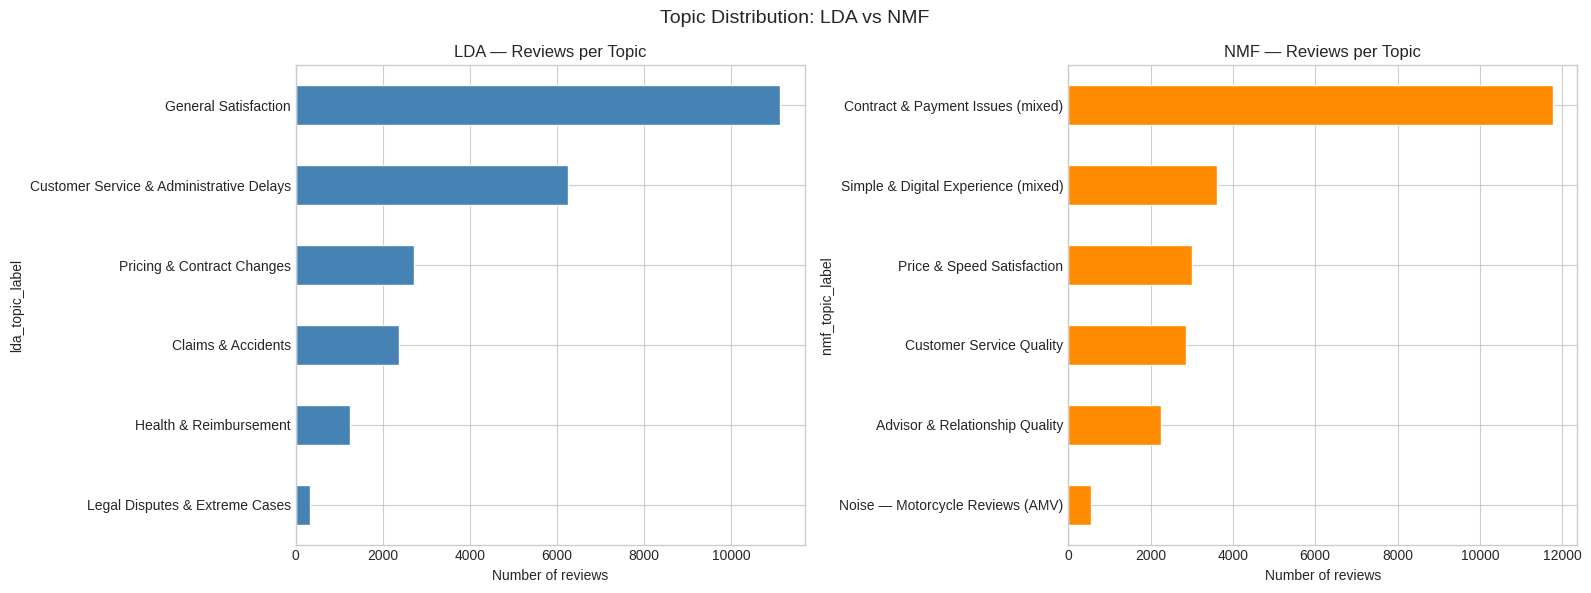

In [ ]:
# Side by side topic distribution: LDA vs NMF
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

lda_counts = df['lda_topic_label'].value_counts()
nmf_counts = df['nmf_topic_label'].value_counts()

lda_counts.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('LDA — Reviews per Topic')
axes[0].set_xlabel('Number of reviews')
axes[0].invert_yaxis()

nmf_counts.plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('NMF — Reviews per Topic')
axes[1].set_xlabel('Number of reviews')
axes[1].invert_yaxis()

plt.suptitle('Topic Distribution: LDA vs NMF', fontsize=14)
plt.tight_layout()
plt.savefig('08_lda_vs_nmf.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Agreement rate: percentage of reviews where both models assign the same topic
agreement = (df['lda_topic_id'] == df['nmf_topic_id']).sum()
agreement_pct = agreement / len(df) * 100

print(f'Reviews where LDA and NMF agree : {agreement:,} ({agreement_pct:.1f}%)')
print(f'Reviews where they disagree     : {len(df) - agreement:,} ({100 - agreement_pct:.1f}%)')
print()

# Cross-tabulation: shows exactly where disagreements happen
print('Cross-tabulation (LDA rows vs NMF columns):')
crosstab = pd.crosstab(
    df['lda_topic_id'].map(TOPIC_LABELS),
    df['nmf_topic_id'].map(NMF_TOPIC_LABELS),
    rownames=['LDA'],
    colnames=['NMF']
)
print(crosstab)

Reviews where LDA and NMF agree : 5,109 (21.2%)
Reviews where they disagree     : 18,956 (78.8%)

Cross-tabulation (LDA rows vs NMF columns):
NMF                                       Advisor & Relationship Quality  \
LDA                                                                        
Claims & Accidents                                                    79   
Customer Service & Administrative Delays                             182   
General Satisfaction                                                1733   
Health & Reimbursement                                                68   
Legal Disputes & Extreme Cases                                        30   
Pricing & Contract Changes                                           166   

NMF                                       Contract & Payment Issues (mixed)  \
LDA                                                                           
Claims & Accidents                                                     2164   
Customer Ser


## 6 Saving the Output


In [ ]:
output_path = r'Traduction avis clients\Traduction avis clients graphiques\insurance_reviews_topics.csv'
df.to_csv(output_path, index=False, encoding='utf-8')

print(f'Saved to : {output_path}')
print(f'Shape    : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns  : {list(df.columns)}')

Saved to : Traduction avis clients\Traduction avis clients graphiques\insurance_reviews_topics.csv
Shape    : 24,065 rows x 16 columns
Columns  : ['note', 'sentiment', 'auteur', 'assureur', 'produit', 'type', 'avis', 'avis_en', 'avis_spell_corrected', 'text_clean', 'tokens', 'lda_topic_id', 'lda_topic_prob', 'lda_topic_label', 'nmf_topic_id', 'nmf_topic_label']
